# Plot: winning variate by patient

Loads the df-normalized top-variate table from `2.per_patient_variate_importance.ipynb` (`results/per_patient_variate_importance/{organoid,single_cell}_top_variate_per_patient_feature.parquet`), restricted to well-explained models (mean R^2 > 0.3), and plots which variate wins most often per patient.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/per_patient_variate_importance"
)
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/per_patient_variate_importance"
)

NON_RESIDUAL_TERMS = [
    "treatment",
    "cell_count",
    "organoid_count",
    "cell_per_organoid_count",
]
top_variate_dfs = {
    name: pd.read_parquet(
        results_path / f"{name}_top_variate_per_patient_feature.parquet"
    )
    for name in ["organoid", "single_cell"]
}

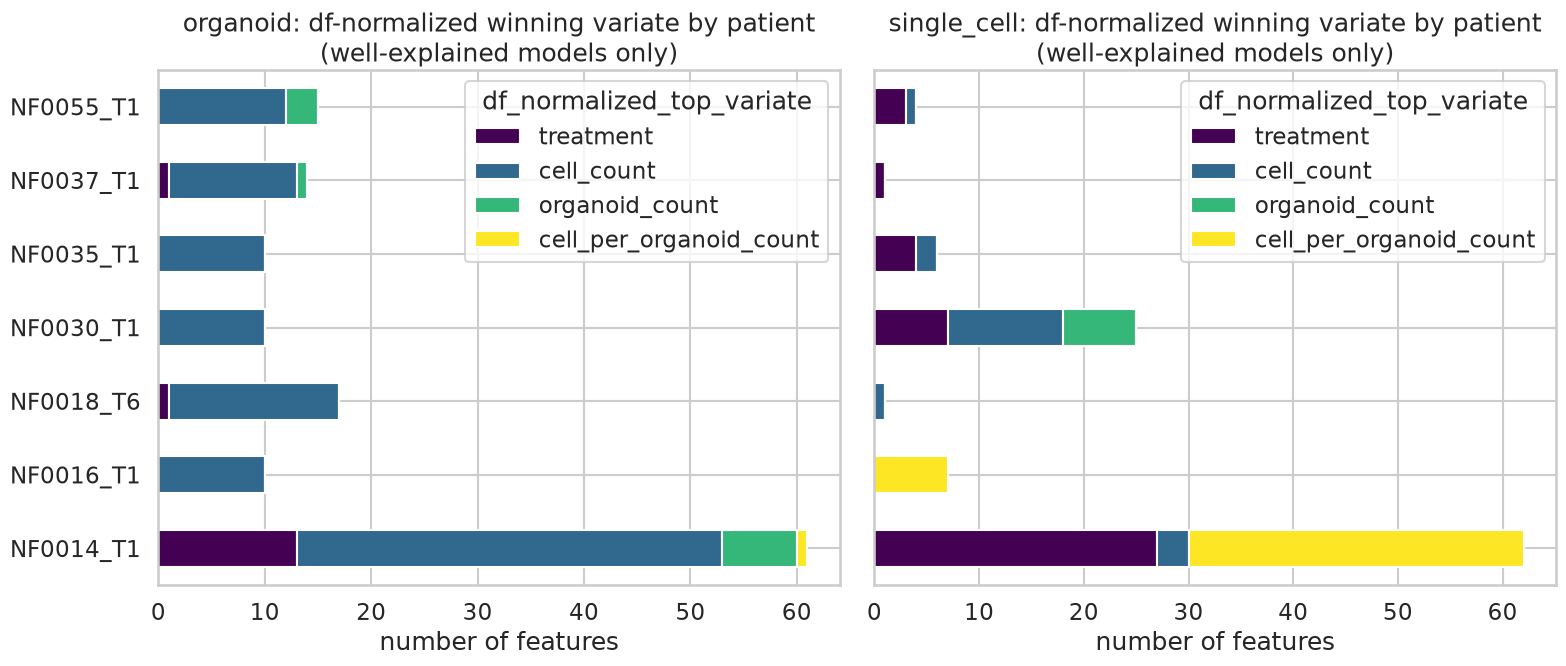

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (name, out) in zip(axes, top_variate_dfs.items()):
    well = out[out["mean_rsquared"] > 0.3]
    counts = (
        well.groupby(["patient", "df_normalized_top_variate"])
        .size()
        .rename("n")
        .reset_index()
    )
    pivot = counts.pivot(
        index="patient", columns="df_normalized_top_variate", values="n"
    ).fillna(0)
    pivot = pivot.reindex(columns=[t for t in NON_RESIDUAL_TERMS if t in pivot.columns])
    pivot.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
    ax.set_title(
        f"{name}: df-normalized winning variate by patient\n(well-explained models only)"
    )
    ax.set_xlabel("number of features")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(figures_path / "top_variate_by_patient.png", dpi=600, bbox_inches="tight")
plt.show()

The df-normalized winner corrects for `treatment` having many more degrees of freedom (one dummy per drug) than a single-slope covariate like `cell_count` — see `2.per_patient_variate_importance.ipynb` for the full raw-vs-df-normalized comparison.